In [8]:
import os, math, random, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision.transforms import RandomErasing, RandomResizedCrop
import torchvision.models as models
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve
)
import rasterio

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
torch.backends.cudnn.benchmark = True

Using device: cuda


In [9]:
class CFG:
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    OUTPUTDIR     = Path('/kaggle/working')

    TRAINSITE     = ROOT / 'train' / 'site'
    TRAINNOSITE   = ROOT / 'train' / 'no_site'
    VALSITE       = ROOT / 'validation' / 'site'
    VALNOSITE     = ROOT / 'validation' / 'no_site'
    TESTSITE      = ROOT / 'test' / 'site'
    TESTNOSITE    = ROOT / 'test' / 'no_site'

    IMGSUFFIX     = '.tif'
    SATBANDS      = [0, 1, 2, 3]
    LIDARBANDS    = [4, 5, 6, 7, 8, 9, 10]
    INCHANNELS    = len(SATBANDS) + len(LIDARBANDS)

    NUMCLASSES    = 1
    IMGSIZE       = 200
    BATCHSIZE     = 32
    NUMEPOCHS     = 40
    BASELR        = 5e-5
    WEIGHTDECAY   = 0.1
    DROPOUT       = 0.6
    SEED          = 42
    NUMWORKERS    = 2
    USEAMP        = torch.cuda.is_available()

    PATIENCE      = 3
    MINDELTA      = 1e-3
    SCHED_FACTOR  = 0.5
    SCHED_PATIENCE = 2

    USEPOSWEIGHT  = False
    USEFOCALLOSS  = False
    FOCALGAMMA    = 2.0
    LABELSMOOTH   = 0.0

    HEADLRMULT    = 5.0
    LLRD          = 0.8
    FREEZEEPOCHS  = 8
    FREEZESTAGES  = 4

    STOCHDEPTH    = 0.3
    MIXUPPROB     = 0.0
    MIXUPALPHA    = 0.4
    ERASEPROB     = 0.10
    CROPSCALE     = (0.85, 1.0)
    SATNOISESTD   = 0.02
    LIDARNOISESTD = 0.05

    STEMNOISESTD  = 1e-4
    RGBDROPPROB   = 0.30
    LIDARDROPPROB = 0.15
    SAT_SCALE     = 10000.0
    IMAGENET_NORM = True

    LIDARNORM     = 'global'
    LIDARCLIP     = 8.0
    EVALTRAINEACHEPOCH = True

In [10]:
def setseed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setseed(CFG.SEED)
CFG.OUTPUTDIR.mkdir(parents=True, exist_ok=True)

In [11]:
def foldertodf(sitedir: Path, nositedir: Path) -> pd.DataFrame:
    rows = [{'filepath': str(f), 'label': l}
            for l, d in [(1, sitedir), (0, nositedir)]
            for f in sorted(d.glob(f'*{CFG.IMGSUFFIX}'))]
    return pd.DataFrame(rows)

print('Scanning dataset folders...')
traindf = foldertodf(CFG.TRAINSITE, CFG.TRAINNOSITE)
valdf   = foldertodf(CFG.VALSITE,   CFG.VALNOSITE)
testdf  = foldertodf(CFG.TESTSITE,  CFG.TESTNOSITE)

print(f"Train: {len(traindf)} | Val: {len(valdf)} | Test: {len(testdf)}")
print(f"Train class balance: {traindf['label'].value_counts().to_dict()}")

Scanning dataset folders...
Train: 3596 | Val: 1245 | Test: 878
Train class balance: {0: 2720, 1: 876}


In [12]:
def loadrawpatch(tifpath: str):
    with rasterio.open(tifpath) as src:
        img = src.read(masked=True).astype(np.float32).filled(0.0)
    sat = img[CFG.SATBANDS] / CFG.SAT_SCALE
    sat = np.clip(sat, 0.0, 1.0)
    return sat, img[CFG.LIDARBANDS]


def buildrawcache(df: pd.DataFrame, splitname: str):
    print(f"Caching {len(df)} {splitname} patches into RAM...")
    sats, lidars, labels = [], [], []
    for row in df.itertuples():
        s, l = loadrawpatch(row.filepath)
        sats.append(s); lidars.append(l); labels.append(float(row.label))
    return sats, lidars, labels


def computelidarstats(lidars):
    n = len(CFG.LIDARBANDS)
    total = np.zeros(n, np.float64)
    totalsq = np.zeros(n, np.float64)
    count = 0
    for l in lidars:
        ld = l.astype(np.float64)
        total   += ld.sum(axis=(1, 2))
        totalsq += (ld ** 2).sum(axis=(1, 2))
        count   += l.shape[1] * l.shape[2]
    mean = total / count
    var = np.maximum(totalsq / count - mean ** 2, 1e-12)
    return mean.astype(np.float32), np.sqrt(var).astype(np.float32)


def normalizelidarperpatch(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr, dtype=np.float32)
    for c, ch in enumerate(arr):
        mean, std = float(np.nanmean(ch)), float(np.nanstd(ch))
        out[c] = ch - mean if std < 1e-4 or np.isnan(std) else (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def finalizecache(sats, lidars, labels, lmean, lstd):
    out = []
    for i in range(len(sats)):
        l = lidars[i]
        if CFG.LIDARNORM == 'global':
            ln = (l - lmean[:, None, None]) / (lstd[:, None, None] + 1e-6)
            ln = np.clip(ln, -CFG.LIDARCLIP, CFG.LIDARCLIP)
        else:
            ln = normalizelidarperpatch(l)
        ln = np.nan_to_num(ln, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
        out.append((np.concatenate([sats[i], ln], axis=0), labels[i]))
        sats[i] = None; lidars[i] = None
    return out

In [13]:
class MultiModalDataset(Dataset):
    def __init__(self, cached, istrain: bool = True):
        self.cached = cached
        self.istrain = istrain
        self.randomerase = RandomErasing(p=CFG.ERASEPROB, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)
        self.randomcrop = RandomResizedCrop(CFG.IMGSIZE, scale=CFG.CROPSCALE, ratio=(0.85, 1.18), antialias=True)
        self.rgb_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.rgb_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.cached)

    def __getitem__(self, idx):
        img, label = self.cached[idx]
        t = torch.from_numpy(img).clone()
        nsat = len(CFG.SATBANDS)

        if CFG.IMAGENET_NORM and nsat >= 3:
            t[:3] = (t[:3] - self.rgb_mean) / self.rgb_std

        if self.istrain:
            t = self.randomcrop(t)
            if random.random() > 0.5: t = TF.hflip(t)
            if random.random() > 0.5: t = TF.vflip(t)
            k = random.choice([0, 1, 2, 3])
            if k: t = torch.rot90(t, k, dims=(1, 2))

            if random.random() > 0.5:
                t[:nsat] += torch.randn_like(t[:nsat]) * CFG.SATNOISESTD
                t[nsat:] += torch.randn_like(t[nsat:]) * CFG.LIDARNOISESTD

            t = self.randomerase(t)

            if random.random() < CFG.RGBDROPPROB:
                satmean = t[0:nsat].mean(dim=(1, 2), keepdim=True)
                t[0:nsat] = satmean.expand_as(t[0:nsat])
            if random.random() < CFG.LIDARDROPPROB:
                t[nsat:] = 0.0
        else:
            if t.shape[-1] != CFG.IMGSIZE or t.shape[-2] != CFG.IMGSIZE:
                t = TF.resize(t, [CFG.IMGSIZE, CFG.IMGSIZE],
                              interpolation=TF.InterpolationMode.BILINEAR, antialias=True)

        return t, torch.tensor(label, dtype=torch.float32)

In [14]:
trnsats, trnlidars, trnlabels_raw = buildrawcache(traindf, "Train")
LIDARMEAN, LIDARSTD = computelidarstats(trnlidars)
print(f"LiDAR channel means: {np.round(LIDARMEAN, 3)}")
print(f"LiDAR channel stds : {np.round(LIDARSTD, 3)}")

traincache = finalizecache(trnsats, trnlidars, trnlabels_raw, LIDARMEAN, LIDARSTD)
del trnsats, trnlidars; gc.collect()

vs, vl, vlab = buildrawcache(valdf, "Val")
valcache = finalizecache(vs, vl, vlab, LIDARMEAN, LIDARSTD)
del vs, vl; gc.collect()

ts, tl, tlab = buildrawcache(testdf, "Test")
testcache = finalizecache(ts, tl, tlab, LIDARMEAN, LIDARSTD)
del ts, tl; gc.collect()

Caching 3596 Train patches into RAM...
LiDAR channel means: [0.026 7.547 0.928 0.631 0.627 0.632 0.637]
LiDAR channel stds : [1.167 6.61  0.063 0.094 0.102 0.094 0.101]
Caching 1245 Val patches into RAM...
Caching 878 Test patches into RAM...


30

In [15]:
counts = traindf['label'].value_counts().to_dict()
sampleweights = [1.0 / counts[lbl] for lbl in traindf['label']]
sampler = WeightedRandomSampler(weights=sampleweights, num_samples=len(traindf), replacement=True)

trnloader      = DataLoader(MultiModalDataset(traincache, True),  batch_size=CFG.BATCHSIZE,
                            sampler=sampler, num_workers=CFG.NUMWORKERS, pin_memory=True, drop_last=True)
trnloader_eval = DataLoader(MultiModalDataset(traincache, False), batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
valloader      = DataLoader(MultiModalDataset(valcache, False),    batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
testloader     = DataLoader(MultiModalDataset(testcache, False),   batch_size=CFG.BATCHSIZE * 2,
                            shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

In [16]:
def createconvnextmodel(inchannels=11, numclasses=1, dropout=CFG.DROPOUT):
    model = models.convnext_tiny(
        weights=models.ConvNeXt_Tiny_Weights.DEFAULT,
        stochastic_depth_prob=CFG.STOCHDEPTH,
    )

    oldconv = model.features[0][0]
    oldinchannels  = oldconv.weight.shape[1]
    oldoutchannels = oldconv.out_channels

    newconv = nn.Conv2d(
        in_channels=inchannels,
        out_channels=oldoutchannels,
        kernel_size=oldconv.kernel_size,
        stride=oldconv.stride,
        padding=oldconv.padding,
        bias=oldconv.bias is not None,
    )

    with torch.no_grad():
        if inchannels == oldinchannels:
            newconv.weight[:] = oldconv.weight
        elif oldinchannels == 3 and inchannels > 3:
            newconv.weight[:, 0:3, :, :] = oldconv.weight
            meanweight = oldconv.weight.mean(dim=1)
            for c in range(3, inchannels):
                newconv.weight[:, c, :, :] = meanweight * 0.25
            newconv.weight[:, 3:inchannels, :, :] *= (oldinchannels / inchannels)
            newconv.weight[:, 3:inchannels, :, :] += torch.randn_like(
                newconv.weight[:, 3:inchannels, :, :]) * CFG.STEMNOISESTD
        else:
            nn.init.kaiming_normal_(newconv.weight, nonlinearity='relu')

        if oldconv.bias is not None:
            newconv.bias.copy_(oldconv.bias)

    model.features[0][0] = newconv
    infeatures = model.classifier[2].in_features
    model.classifier = nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        nn.Dropout(p=dropout),
        nn.Linear(infeatures, numclasses),
    )
    return model

In [17]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        ptcorrect = torch.where(targets >= 0.5, probs, 1 - probs)
        focalterm = (1 - ptcorrect).clamp(min=1e-6).pow(self.gamma)
        loss = focalterm * bce
        if self.pos_weight is not None:
            alphaweight = torch.where(targets >= 0.5, self.pos_weight, torch.ones_like(targets))
            loss = loss * alphaweight
        return loss.mean()

posweighttensor = None
if CFG.USEPOSWEIGHT:
    posweighttensor = torch.tensor([counts.get(0, 0) / max(counts.get(1, 1), 1)],
                                   dtype=torch.float32).to(DEVICE)

criterion = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=posweighttensor)
             if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=posweighttensor))

In [18]:
def ishead(name: str) -> bool:
    return name.startswith('features.0.0') or name.startswith('features.0.1') or name.startswith('classifier')

def stagedepth(name: str) -> int:
    if name.startswith('classifier'): return 8
    if name.startswith('features.'): return int(name.split('.')[1])
    return 0

def freezeearlystages(model, upto: int):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            if int(name.split('.')[1]) < upto:
                p.requires_grad = False

def setbackbonefrozen(model, frozen: bool):
    for name, p in model.named_parameters():
        if ishead(name):
            p.requires_grad = True
            continue
        if name.startswith('features.'):
            stage = int(name.split('.')[1])
            if stage < CFG.FREEZESTAGES:
                continue
        p.requires_grad = not frozen

def buildparamgroups(model, baselr, weightdecay, headlrmult, llrd):
    maxdepth = 8
    buckets = {}
    for name, p in model.named_parameters():
        lr = baselr * headlrmult if ishead(name) else baselr * (llrd ** (maxdepth - stagedepth(name)))
        wd = 0.0 if (p.ndim <= 1 or 'norm' in name.lower() or 'layer_scale' in name.lower()) else weightdecay
        buckets.setdefault((round(lr, 12), wd), []).append((name, p))

    groups = []
    for (lr, wd), items in sorted(buckets.items()):
        groups.append({'params': [p for _, p in items], 'lr': lr, 'weight_decay': wd})
    return groups

In [19]:
model = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
freezeearlystages(model, CFG.FREEZESTAGES)
setbackbonefrozen(model, frozen=True)

optimizer = optim.AdamW(buildparamgroups(model, CFG.BASELR, CFG.WEIGHTDECAY, CFG.HEADLRMULT, CFG.LLRD))
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=CFG.SCHED_FACTOR,
                                                 patience=CFG.SCHED_PATIENCE, min_lr=1e-6)
scaler = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)
backbonefrozen = True

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 217MB/s] 


In [20]:
def computemetrics(ytrue, ypred):
    auc   = roc_auc_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    prauc = average_precision_score(ytrue, ypred) if len(set(ytrue)) > 1 else 0.0
    binpreds = [1 if p >= 0.5 else 0 for p in ypred]
    return (auc, prauc,
            precision_score(ytrue, binpreds, zero_division=0),
            recall_score(ytrue, binpreds, zero_division=0),
            f1_score(ytrue, binpreds, zero_division=0),
            accuracy_score(ytrue, binpreds))


def trainepoch(model, loader, optimizer, scaler):
    model.train()
    totalloss, seen = 0.0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        target = (labels * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH
                  if CFG.LABELSMOOTH > 0 else labels)

        if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
            lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
            perm = torch.randperm(inputs.size(0), device=DEVICE)
            inputs = lam * inputs + (1 - lam) * inputs[perm]
            target = lam * target + (1 - lam) * target[perm]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, target)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
    return totalloss / max(seen, 1)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    totalloss, seen, alllabels, allpreds = 0.0, 0, [], []
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
            logits = model(inputs).squeeze(1)
            loss = criterion(logits, labels)
        bs = labels.size(0)
        totalloss += loss.item() * bs
        seen += bs
        allpreds.extend(np.nan_to_num(torch.sigmoid(logits).float().cpu().numpy(), nan=0.5))
        alllabels.extend(labels.cpu().numpy())
    return (totalloss / max(seen, 1), *computemetrics(alllabels, allpreds), alllabels, allpreds)

In [21]:
bestvalauc = 0.0
epochsnoimprove = 0
ckptpath = CFG.OUTPUTDIR / 'convnext_tiny_multimodal_best.pth'

history = {'epoch': [], 'trn_loss': [], 'val_loss': [],
           'trn_roc_auc': [], 'val_roc_auc': [],
           'trn_pr_auc': [], 'val_pr_auc': [],
           'trn_f1': [], 'val_f1': []}

print(f'\n{"="*78}\n  ConvNeXt-Tiny | 11-channel multimodal | max {CFG.NUMEPOCHS} epochs, patience {CFG.PATIENCE}\n{"="*78}')

for epoch in range(1, CFG.NUMEPOCHS + 1):
    if backbonefrozen and epoch > CFG.FREEZEEPOCHS:
        setbackbonefrozen(model, frozen=False)
        backbonefrozen = False
        epochsnoimprove = 0
        print(f'  -> Unfroze backbone at epoch {epoch}')

    trnloss = trainepoch(model, trnloader, optimizer, scaler)
    valloss, valauc, valprauc, valprec, valrec, valf1, valacc, _, _ = evaluate(model, valloader)

    if not backbonefrozen:
        scheduler.step(valauc)

    if CFG.EVALTRAINEACHEPOCH:
        ctrnloss, trnauc, trnprauc, _, _, trnf1, _, _, _ = evaluate(model, trnloader_eval)
    else:
        ctrnloss, trnauc, trnprauc, trnf1 = trnloss, 0.0, 0.0, 0.0

    history['epoch'].append(epoch)
    history['trn_loss'].append(ctrnloss)
    history['val_loss'].append(valloss)
    history['trn_roc_auc'].append(trnauc)
    history['val_roc_auc'].append(valauc)
    history['trn_pr_auc'].append(trnprauc)
    history['val_pr_auc'].append(valprauc)
    history['trn_f1'].append(trnf1)
    history['val_f1'].append(valf1)

    saved = ''
    if valauc > bestvalauc + CFG.MINDELTA:
        bestvalauc = valauc
        epochsnoimprove = 0
        torch.save(model.state_dict(), ckptpath)
        saved = '  ✓ saved'
    else:
        if not backbonefrozen:
            epochsnoimprove += 1

    headlr = max(g['lr'] for g in optimizer.param_groups)
    print(f'Ep {epoch:02d}/{CFG.NUMEPOCHS} | head LR: {headlr:.2e} | '
          f'clean AUC gap: {trnauc - valauc:+.4f} | patience: {epochsnoimprove}/{CFG.PATIENCE}{saved}')
    print(f'  Train (aug)   -> Loss: {trnloss:.4f}')
    print(f'  Train (clean) -> Loss: {ctrnloss:.4f} | ROC-AUC: {trnauc:.4f} | PR-AUC: {trnprauc:.4f} | F1: {trnf1:.4f}')
    print(f'  Val           -> Loss: {valloss:.4f} | ROC-AUC: {valauc:.4f} | PR-AUC: {valprauc:.4f} | F1: {valf1:.4f}')

    if not backbonefrozen and epochsnoimprove >= CFG.PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}: val ROC-AUC flat for {CFG.PATIENCE} epochs.')
        break


  ConvNeXt-Tiny | 11-channel multimodal | max 40 epochs, patience 3
Ep 01/40 | head LR: 2.50e-04 | clean AUC gap: -0.0213 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.7125
  Train (clean) -> Loss: 0.6690 | ROC-AUC: 0.5855 | PR-AUC: 0.3106 | F1: 0.3654
  Val           -> Loss: 0.6626 | ROC-AUC: 0.6069 | PR-AUC: 0.3430 | F1: 0.3599
Ep 02/40 | head LR: 2.50e-04 | clean AUC gap: -0.0350 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6992
  Train (clean) -> Loss: 0.6484 | ROC-AUC: 0.5881 | PR-AUC: 0.3158 | F1: 0.2961
  Val           -> Loss: 0.6410 | ROC-AUC: 0.6231 | PR-AUC: 0.3524 | F1: 0.2642
Ep 03/40 | head LR: 2.50e-04 | clean AUC gap: -0.0243 | patience: 0/3  ✓ saved
  Train (aug)   -> Loss: 0.6897
  Train (clean) -> Loss: 0.6788 | ROC-AUC: 0.6303 | PR-AUC: 0.3465 | F1: 0.4158
  Val           -> Loss: 0.6618 | ROC-AUC: 0.6546 | PR-AUC: 0.3872 | F1: 0.4587
Ep 04/40 | head LR: 2.50e-04 | clean AUC gap: -0.0263 | patience: 0/3
  Train (aug)   -> Loss: 0.6921
  Train (clean) 

In [22]:
if ckptpath.exists() and bestvalauc > 0.0:
    model.load_state_dict(torch.load(ckptpath, map_location=DEVICE, weights_only=True))
    model.eval()

    _, _, _, _, _, _, _, trnlabels, trnpreds  = evaluate(model, trnloader_eval)
    _, _, _, _, _, _, _, vallabels, valpreds  = evaluate(model, valloader)
    _, tstauc, tstprauc, _, _, _, _, testlabels, testpreds = evaluate(model, testloader)

    valprauc_best = average_precision_score(vallabels, valpreds)
    valprecisions, valrecalls, valthresholds = precision_recall_curve(vallabels, valpreds)
    f1_scores = 2 * (valprecisions[:-1] * valrecalls[:-1]) / (valprecisions[:-1] + valrecalls[:-1] + 1e-8)
    bestthresh = float(valthresholds[np.argmax(f1_scores)])

    testpredsnp, testlabelsnp = np.array(testpreds), np.array(testlabels)
    bindefault = (testpredsnp >= 0.5).astype(int)
    binopt     = (testpredsnp >= bestthresh).astype(int)

    print("\n" + "=" * 68 + "\n      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)\n" + "=" * 68)
    print(f"Threshold-free   -> ROC-AUC: {tstauc:.4f} | PR-AUC: {tstprauc:.4f}")
    print(f"Optimal threshold calibrated on val: {bestthresh:.4f}")

    for tag, binp in [("Default (0.50)", bindefault), (f"Calibrated ({bestthresh:.4f})", binopt)]:
        print(f"\nTest @ {tag}:")
        print(f"  • Precision : {precision_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Recall    : {recall_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • F1-Score  : {f1_score(testlabelsnp, binp, zero_division=0):.4f}")
        print(f"  • Accuracy  : {accuracy_score(testlabelsnp, binp):.4f}")
    print("=" * 68)


      FINAL BENCHMARK: UNTOUCHED TEST SET (CONVNEXT-TINY)
Threshold-free   -> ROC-AUC: 0.7746 | PR-AUC: 0.6270
Optimal threshold calibrated on val: 0.5850

Test @ Default (0.50):
  • Precision : 0.4650
  • Recall    : 0.6460
  • F1-Score  : 0.5407
  • Accuracy  : 0.7175

Test @ Calibrated (0.5850):
  • Precision : 0.5556
  • Recall    : 0.5088
  • F1-Score  : 0.5312
  • Accuracy  : 0.7688


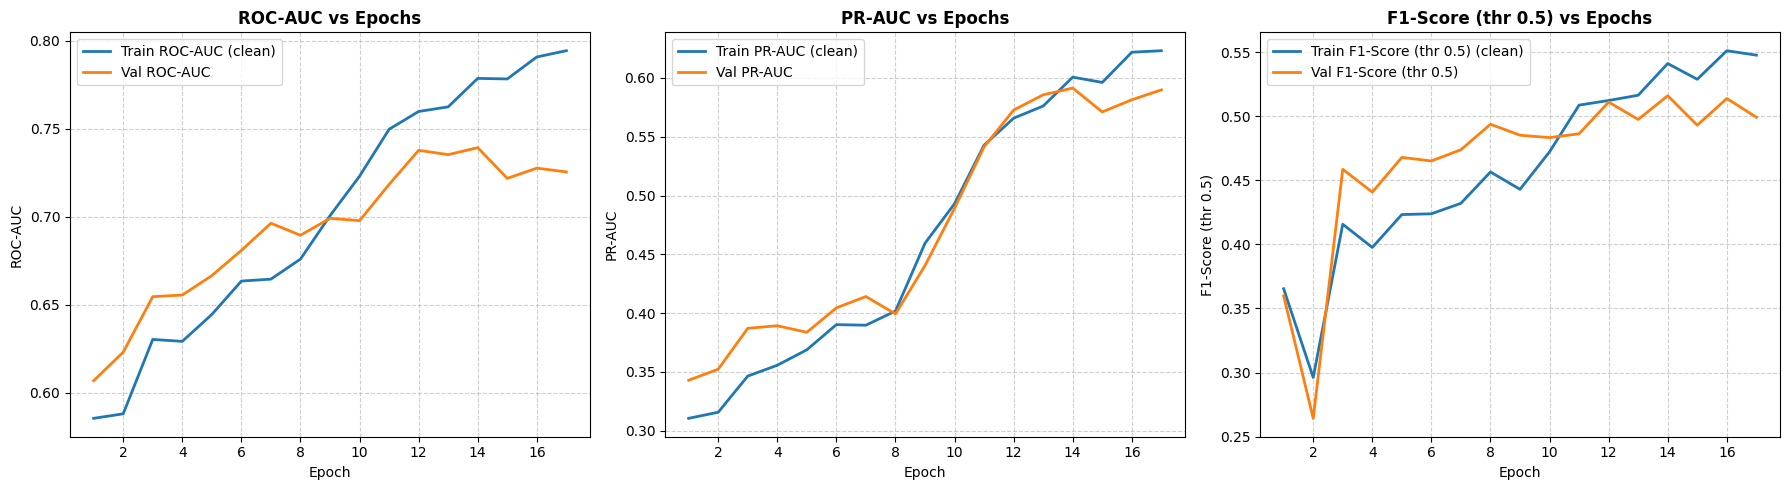

In [23]:
epochs = history['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (trnkey, valkey, name) in zip(axes, [
    ('trn_roc_auc', 'val_roc_auc', 'ROC-AUC'),
    ('trn_pr_auc',  'val_pr_auc',  'PR-AUC'),
    ('trn_f1',      'val_f1',      'F1-Score (thr 0.5)'),
]):
    ax.plot(epochs, history[trnkey], label=f'Train {name} (clean)', color='tab:blue', lw=2)
    ax.plot(epochs, history[valkey], label=f'Val {name}', color='tab:orange', lw=2)
    ax.set_title(f'{name} vs Epochs', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(name)
    ax.grid(True, linestyle='--', alpha=0.6); ax.legend()
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'metrics_progression.png', dpi=300)
plt.show()

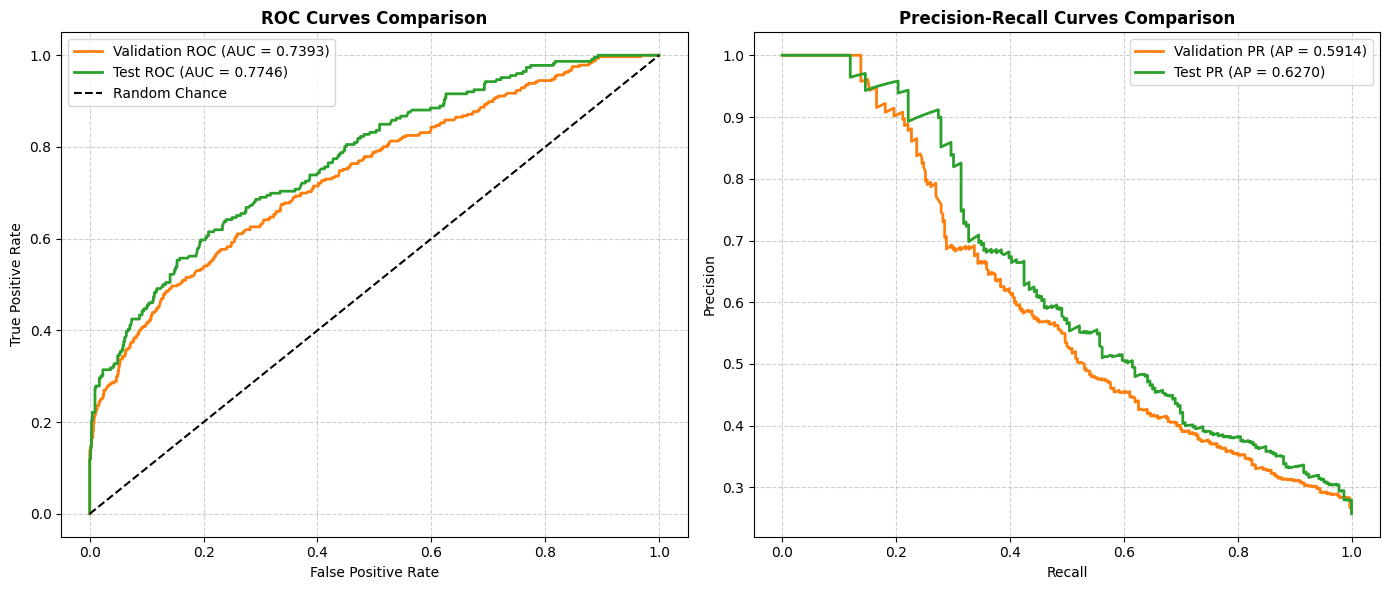

In [24]:
val_fpr, val_tpr, _ = roc_curve(vallabels, valpreds)
tst_fpr, tst_tpr, _ = roc_curve(testlabels, testpreds)
val_prec_c, val_rec_c, _ = precision_recall_curve(vallabels, valpreds)
tst_prec_c, tst_rec_c, _ = precision_recall_curve(testlabels, testpreds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(val_fpr, val_tpr, label=f'Validation ROC (AUC = {bestvalauc:.4f})', color='tab:orange', lw=2)
axes[0].plot(tst_fpr, tst_tpr, label=f'Test ROC (AUC = {tstauc:.4f})', color='tab:green', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[0].set_title('ROC Curves Comparison', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].grid(True, linestyle='--', alpha=0.6); axes[0].legend()

axes[1].plot(val_rec_c, val_prec_c, label=f'Validation PR (AP = {valprauc_best:.4f})', color='tab:orange', lw=2)
axes[1].plot(tst_rec_c, tst_prec_c, label=f'Test PR (AP = {tstprauc:.4f})', color='tab:green', lw=2)
axes[1].set_title('Precision-Recall Curves Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].grid(True, linestyle='--', alpha=0.6); axes[1].legend()

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'roc_pr_curves_comparison.png', dpi=300)
plt.show()

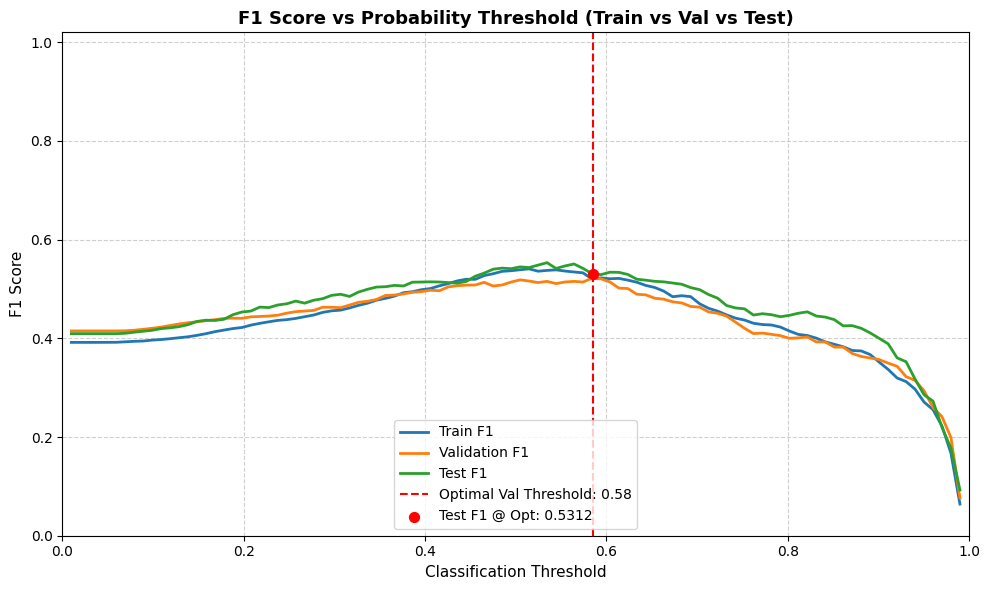

In [25]:
thresh_range = np.linspace(0.01, 0.99, 100)
trnpredsnp, valpredsnp = np.array(trnpreds), np.array(valpreds)
trn_f1_curve = [f1_score(trnlabels,  (trnpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
val_f1_curve = [f1_score(vallabels,  (valpredsnp  >= t).astype(int), zero_division=0) for t in thresh_range]
tst_f1_curve = [f1_score(testlabels, (testpredsnp >= t).astype(int), zero_division=0) for t in thresh_range]

plt.figure(figsize=(10, 6))
plt.plot(thresh_range, trn_f1_curve, label='Train F1', color='tab:blue', lw=2)
plt.plot(thresh_range, val_f1_curve, label='Validation F1', color='tab:orange', lw=2)
plt.plot(thresh_range, tst_f1_curve, label='Test F1', color='tab:green', lw=2)
plt.axvline(x=bestthresh, color='red', linestyle='--', lw=1.5,
            label=f'Optimal Val Threshold: {bestthresh:.2f}')
test_f1_at_opt = f1_score(testlabelsnp, binopt, zero_division=0)
plt.scatter([bestthresh], [test_f1_at_opt], color='red', s=50, zorder=5,
            label=f'Test F1 @ Opt: {test_f1_at_opt:.4f}')
plt.title('F1 Score vs Probability Threshold (Train vs Val vs Test)', fontsize=13, fontweight='bold')
plt.xlabel('Classification Threshold', fontsize=11); plt.ylabel('F1 Score', fontsize=11)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.02])
plt.grid(True, linestyle='--', alpha=0.6); plt.legend(loc='lower center', fontsize=10)
plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / '3in1_f1_threshold_curve.png', dpi=300)
plt.show()

gc.collect()
torch.cuda.empty_cache()


  PERMUTATION TEST (H0: predictions independent of labels)
Permutations: 2000
Test class balance: 0.2574 positive (226/878)

Metric       Observed    Null mean     Null std    Z-score      p-value
----------------------------------------------------------------------
PR-AUC         0.6270       0.2625       0.0155     23.543     0.000500
ROC-AUC        0.7746       0.4995       0.0228     12.045     0.000500

  -> PR-AUC significantly better than chance (p < 0.001).
  -> ROC-AUC significantly better than chance (p < 0.001).


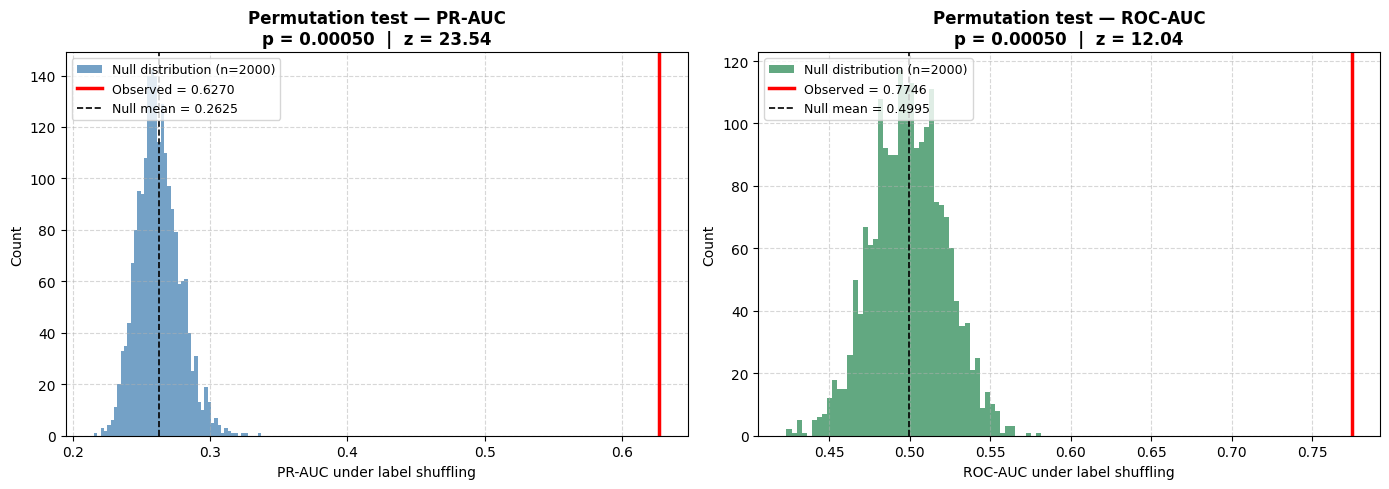

Saved: permutation_null_distributions.npz


In [26]:
# ==========================================
# PERMUTATION TEST — Is the model better than chance?
# ==========================================
# H0: predictions are independent of labels.
# Shuffle test labels N times, recompute metric, compare.
# p-value = fraction of null metrics >= observed.

print('\n' + '=' * 68)
print('  PERMUTATION TEST (H0: predictions independent of labels)')
print('=' * 68)

N_PERM = 2000
rng = np.random.default_rng(CFG.SEED)

testpredsnp  = np.asarray(testpreds,  dtype=np.float64)
testlabelsnp = np.asarray(testlabels, dtype=np.int64)

obs_pr  = average_precision_score(testlabelsnp, testpredsnp)
obs_roc = roc_auc_score(testlabelsnp, testpredsnp)

null_pr  = np.empty(N_PERM, dtype=np.float64)
null_roc = np.empty(N_PERM, dtype=np.float64)

for i in range(N_PERM):
    shuf = rng.permutation(testlabelsnp)
    if len(np.unique(shuf)) < 2:
        null_pr[i], null_roc[i] = 0.0, 0.5
        continue
    null_pr[i]  = average_precision_score(shuf, testpredsnp)
    null_roc[i] = roc_auc_score(shuf, testpredsnp)

# +1 correction so p is never exactly zero
p_pr  = (np.sum(null_pr  >= obs_pr)  + 1) / (N_PERM + 1)
p_roc = (np.sum(null_roc >= obs_roc) + 1) / (N_PERM + 1)

z_pr  = (obs_pr  - null_pr.mean())  / (null_pr.std()  + 1e-12)
z_roc = (obs_roc - null_roc.mean()) / (null_roc.std() + 1e-12)

print(f'Permutations: {N_PERM}')
print(f'Test class balance: {testlabelsnp.mean():.4f} positive '
      f'({testlabelsnp.sum()}/{len(testlabelsnp)})')
print()
print(f'{"Metric":<10} {"Observed":>10} {"Null mean":>12} {"Null std":>12} '
      f'{"Z-score":>10} {"p-value":>12}')
print('-' * 70)
print(f'{"PR-AUC":<10} {obs_pr:>10.4f} {null_pr.mean():>12.4f} '
      f'{null_pr.std():>12.4f} {z_pr:>10.3f} {p_pr:>12.6f}')
print(f'{"ROC-AUC":<10} {obs_roc:>10.4f} {null_roc.mean():>12.4f} '
      f'{null_roc.std():>12.4f} {z_roc:>10.3f} {p_roc:>12.6f}')
print()

if p_pr < 0.001:
    print('  -> PR-AUC significantly better than chance (p < 0.001).')
elif p_pr < 0.05:
    print('  -> PR-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> PR-AUC NOT significant at p < 0.05.')

if p_roc < 0.001:
    print('  -> ROC-AUC significantly better than chance (p < 0.001).')
elif p_roc < 0.05:
    print('  -> ROC-AUC significantly better than chance (p < 0.05).')
else:
    print('  -> ROC-AUC NOT significant at p < 0.05.')

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(null_pr, bins=50, color='steelblue', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(null_pr.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_pr.mean():.4f}')
ax.set_title(f'Permutation test — PR-AUC\np = {p_pr:.5f}  |  z = {z_pr:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PR-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

ax = axes[1]
ax.hist(null_roc, bins=50, color='seagreen', alpha=0.75,
        label=f'Null distribution (n={N_PERM})')
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(null_roc.mean(), color='black', lw=1.2, ls='--',
           label=f'Null mean = {null_roc.mean():.4f}')
ax.set_title(f'Permutation test — ROC-AUC\np = {p_roc:.5f}  |  z = {z_roc:.2f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('ROC-AUC under label shuffling')
ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'permutation_test.png', dpi=300)
plt.show()

np.savez(CFG.OUTPUTDIR / 'permutation_null_distributions.npz',
         null_pr=null_pr, null_roc=null_roc,
         obs_pr=obs_pr, obs_roc=obs_roc,
         p_pr=p_pr, p_roc=p_roc, n_perm=N_PERM)
print('Saved: permutation_null_distributions.npz')
print('=' * 68)


  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)
Metric          Point   Median               95% CI
----------------------------------------------------
ROC-AUC        0.7746   0.7750    [0.7387 – 0.8083]
PR-AUC         0.6270   0.6293    [0.5672 – 0.6845]
F1                  -   0.5310    [0.4742 – 0.5877]
Precision           -   0.5550    [0.4878 – 0.6230]
Recall              -   0.5088    [0.4444 – 0.5742]


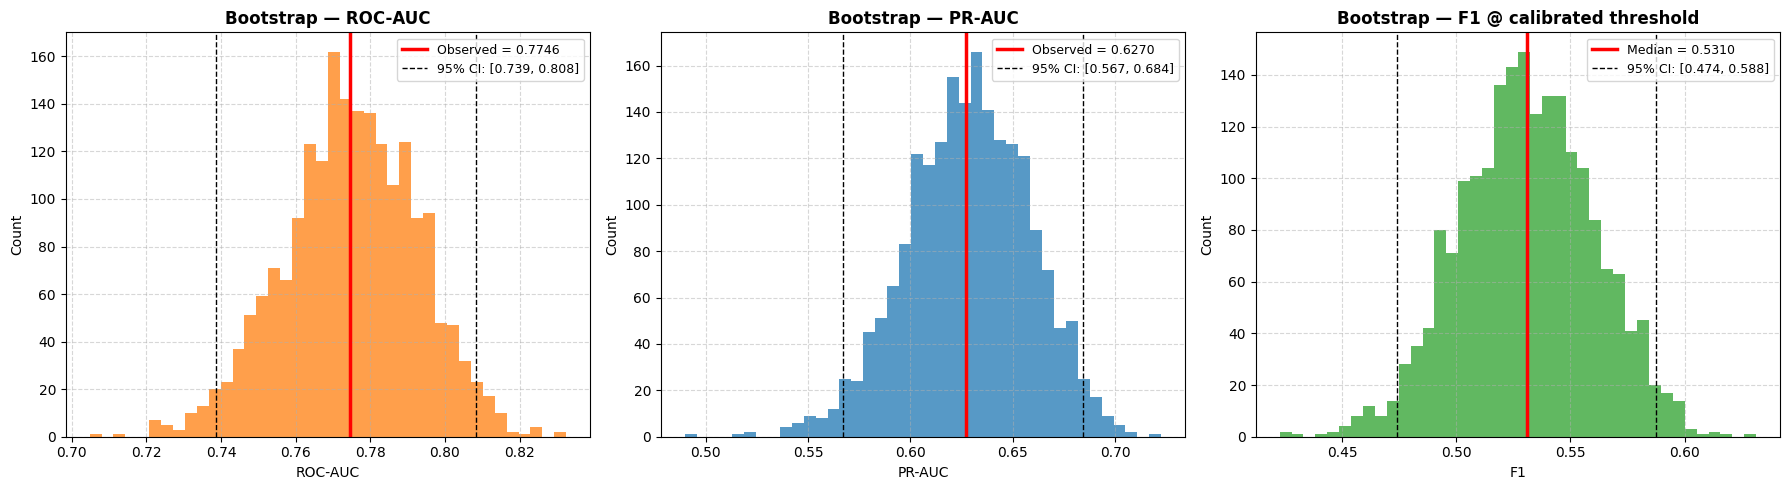

Saved: bootstrap_distributions.npz


In [27]:
# ==========================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS
# ==========================================
# Resample the test set N times with replacement.
# Compute metric on each resample. Report the 2.5 / 50 / 97.5 quantiles.

def bootstrap_ci(y_true, y_pred, metric_fn, n=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n_samples = len(y_true)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        yt = y_true[idx]
        yp = y_pred[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    scores = np.array(scores)
    return (np.quantile(scores, alpha / 2),
            np.quantile(scores, 0.5),
            np.quantile(scores, 1 - alpha / 2),
            scores)

print('\n' + '=' * 68)
print('  BOOTSTRAP 95% CONFIDENCE INTERVALS (n=2000)')
print('=' * 68)

# --- Threshold-free metrics ---
lo_pr,  med_pr,  hi_pr,  pr_scores  = bootstrap_ci(testlabelsnp, testpredsnp, average_precision_score)
lo_roc, med_roc, hi_roc, roc_scores = bootstrap_ci(testlabelsnp, testpredsnp, roc_auc_score)

# --- F1 at calibrated threshold ---
def f1_at_thr(yt, yp):
    return f1_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_f1, med_f1, hi_f1, f1_scores = bootstrap_ci(testlabelsnp, testpredsnp, f1_at_thr)

# --- Precision and Recall at calibrated threshold ---
def prec_at_thr(yt, yp):
    return precision_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

def rec_at_thr(yt, yp):
    return recall_score(yt, (np.asarray(yp) >= bestthresh).astype(int), zero_division=0)

lo_prec, med_prec, hi_prec, _ = bootstrap_ci(testlabelsnp, testpredsnp, prec_at_thr)
lo_rec,  med_rec,  hi_rec,  _ = bootstrap_ci(testlabelsnp, testpredsnp, rec_at_thr)

print(f'{"Metric":<12} {"Point":>8} {"Median":>8} {"95% CI":>20}')
print('-' * 52)
print(f'{"ROC-AUC":<12} {obs_roc:>8.4f} {med_roc:>8.4f} '
      f'   [{lo_roc:.4f} – {hi_roc:.4f}]')
print(f'{"PR-AUC":<12} {obs_pr:>8.4f} {med_pr:>8.4f} '
      f'   [{lo_pr:.4f} – {hi_pr:.4f}]')
print(f'{"F1":<12} {"-":>8} {med_f1:>8.4f} '
      f'   [{lo_f1:.4f} – {hi_f1:.4f}]')
print(f'{"Precision":<12} {"-":>8} {med_prec:>8.4f} '
      f'   [{lo_prec:.4f} – {hi_prec:.4f}]')
print(f'{"Recall":<12} {"-":>8} {med_rec:>8.4f} '
      f'   [{lo_rec:.4f} – {hi_rec:.4f}]')
print('=' * 68)

# ---------- Plots ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(roc_scores, bins=40, color='tab:orange', alpha=0.75)
ax.axvline(obs_roc, color='red', lw=2.5, label=f'Observed = {obs_roc:.4f}')
ax.axvline(lo_roc, color='black', lw=1, ls='--', label=f'95% CI: [{lo_roc:.3f}, {hi_roc:.3f}]')
ax.axvline(hi_roc, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — ROC-AUC', fontweight='bold')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[1]
ax.hist(pr_scores, bins=40, color='tab:blue', alpha=0.75)
ax.axvline(obs_pr, color='red', lw=2.5, label=f'Observed = {obs_pr:.4f}')
ax.axvline(lo_pr, color='black', lw=1, ls='--', label=f'95% CI: [{lo_pr:.3f}, {hi_pr:.3f}]')
ax.axvline(hi_pr, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — PR-AUC', fontweight='bold')
ax.set_xlabel('PR-AUC'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

ax = axes[2]
ax.hist(f1_scores, bins=40, color='tab:green', alpha=0.75)
ax.axvline(med_f1, color='red', lw=2.5, label=f'Median = {med_f1:.4f}')
ax.axvline(lo_f1, color='black', lw=1, ls='--', label=f'95% CI: [{lo_f1:.3f}, {hi_f1:.3f}]')
ax.axvline(hi_f1, color='black', lw=1, ls='--')
ax.set_title('Bootstrap — F1 @ calibrated threshold', fontweight='bold')
ax.set_xlabel('F1'); ax.set_ylabel('Count')
ax.grid(True, ls='--', alpha=0.5); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'bootstrap_ci.png', dpi=300)
plt.show()

# Save arrays for the paper
np.savez(CFG.OUTPUTDIR / 'bootstrap_distributions.npz',
         pr_scores=pr_scores, roc_scores=roc_scores, f1_scores=f1_scores,
         obs_pr=obs_pr, obs_roc=obs_roc)
print('Saved: bootstrap_distributions.npz')

In [28]:
def stratified_subsample(df, frac, seed):
    """Return a stratified subsample of df with the same pos:neg ratio.
    If frac >= 1.0, returns df unchanged."""
    if frac >= 1.0:
        return df.copy()
    rng = np.random.default_rng(seed)
    parts = []
    for label in sorted(df['label'].unique()):
        sub = df[df['label'] == label]
        n = max(1, int(round(frac * len(sub))))
        idx = rng.choice(len(sub), size=n, replace=False)
        parts.append(sub.iloc[idx])
    return pd.concat(parts, ignore_index=True).sample(
        frac=1.0, random_state=seed).reset_index(drop=True)

In [29]:
def train_one_run(df_train, df_val, df_test, run_seed=42, run_tag='lc'):
    """Full training run from scratch. Returns dict of metrics."""
    setseed(run_seed)

    # ---------- Cache ----------
    s_tr, l_tr, y_tr = buildrawcache(df_train, f'{run_tag}-tr')
    tr_cache = finalizecache(s_tr, l_tr, y_tr, LIDARMEAN, LIDARSTD)
    del s_tr, l_tr; gc.collect()

    s_v, l_v, y_v = buildrawcache(df_val, f'{run_tag}-va')
    va_cache = finalizecache(s_v, l_v, y_v, LIDARMEAN, LIDARSTD)
    del s_v, l_v; gc.collect()

    s_t, l_t, y_t = buildrawcache(df_test, f'{run_tag}-te')
    te_cache = finalizecache(s_t, l_t, y_t, LIDARMEAN, LIDARSTD)
    del s_t, l_t; gc.collect()

    # ---------- Sampler ----------
    cnt = df_train['label'].value_counts().to_dict()
    if cnt.get(0, 0) == 0 or cnt.get(1, 0) == 0:
        print(f'  [{run_tag}] SKIP — degenerate subset '
              f'(pos={cnt.get(1,0)}, neg={cnt.get(0,0)})')
        return {'run_tag': run_tag, 'error': 'degenerate',
                'n_train': len(df_train), 'frac': None}

    weights = [1.0 / cnt[lbl] for lbl in df_train['label']]
    smp = WeightedRandomSampler(weights=weights,
                                num_samples=len(df_train),
                                replacement=True)

    trn_ld    = DataLoader(MultiModalDataset(tr_cache, True),  batch_size=CFG.BATCHSIZE,
                           sampler=smp, num_workers=CFG.NUMWORKERS,
                           pin_memory=True, drop_last=True)
    trn_ld_ev = DataLoader(MultiModalDataset(tr_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    va_ld     = DataLoader(MultiModalDataset(va_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)
    te_ld     = DataLoader(MultiModalDataset(te_cache, False), batch_size=CFG.BATCHSIZE * 2,
                           shuffle=False, num_workers=CFG.NUMWORKERS, pin_memory=True)

    # ---------- Model / optim / sched / loss ----------
    mdl = createconvnextmodel(CFG.INCHANNELS, CFG.NUMCLASSES, CFG.DROPOUT).to(DEVICE)
    freezeearlystages(mdl, CFG.FREEZESTAGES)
    setbackbonefrozen(mdl, frozen=True)

    opt = optim.AdamW(buildparamgroups(mdl, CFG.BASELR, CFG.WEIGHTDECAY,
                                       CFG.HEADLRMULT, CFG.LLRD))
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max',
                                               factor=CFG.SCHED_FACTOR,
                                               patience=CFG.SCHED_PATIENCE,
                                               min_lr=1e-6)
    scl = torch.amp.GradScaler(device=DEVICE.type, enabled=CFG.USEAMP)

    pos_weight_t = None
    if CFG.USEPOSWEIGHT:
        pos_weight_t = torch.tensor([cnt.get(0, 1) / max(cnt.get(1, 1), 1)],
                                    dtype=torch.float32).to(DEVICE)
    crit = (FocalLoss(gamma=CFG.FOCALGAMMA, pos_weight=pos_weight_t)
            if CFG.USEFOCALLOSS else nn.BCEWithLogitsLoss(pos_weight=pos_weight_t))

    def _train_ep(m, ld, o, sc):
        m.train()
        tl, seen = 0.0, 0
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            tgt = (y * (1 - CFG.LABELSMOOTH) + 0.5 * CFG.LABELSMOOTH) \
                  if CFG.LABELSMOOTH > 0 else y
            if CFG.MIXUPPROB > 0 and random.random() < CFG.MIXUPPROB:
                lam = float(np.random.beta(CFG.MIXUPALPHA, CFG.MIXUPALPHA))
                perm = torch.randperm(x.size(0), device=DEVICE)
                x = lam * x + (1 - lam) * x[perm]
                tgt = lam * tgt + (1 - lam) * tgt[perm]
            o.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, tgt)
            sc.scale(ls).backward()
            sc.unscale_(o)
            torch.nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
            sc.step(o)
            sc.update()
            tl += ls.item() * x.size(0)
            seen += x.size(0)
        return tl / max(seen, 1)

    @torch.no_grad()
    def _eval(m, ld):
        m.eval()
        tl, seen, ys, ps = 0.0, 0, [], []
        for x, y in ld:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with torch.amp.autocast(device_type=DEVICE.type, enabled=CFG.USEAMP):
                lg = m(x).squeeze(1)
                ls = crit(lg, y)
            tl += ls.item() * x.size(0)
            seen += x.size(0)
            ps.extend(np.nan_to_num(torch.sigmoid(lg).float().cpu().numpy(),
                                    nan=0.5))
            ys.extend(y.cpu().numpy())
        return tl / max(seen, 1), ys, ps

    # ---------- Train ----------
    ckpt = CFG.OUTPUTDIR / f'{run_tag}_best.pth'
    best_auc = 0.0
    no_imp = 0
    frozen = True

    for ep in range(1, CFG.NUMEPOCHS + 1):
        if frozen and ep > CFG.FREEZEEPOCHS:
            setbackbonefrozen(mdl, frozen=False)
            frozen = False
            no_imp = 0

        _train_ep(mdl, trn_ld, opt, scl)
        _, vy, vp = _eval(mdl, va_ld)
        vauc = roc_auc_score(vy, vp) if len(set(vy)) > 1 else 0.0

        if not frozen:
            sch.step(vauc)

        if vauc > best_auc + CFG.MINDELTA:
            best_auc = vauc
            no_imp = 0
            torch.save(mdl.state_dict(), ckpt)
        else:
            if not frozen:
                no_imp += 1

        if ep % 5 == 0 or ep == 1:
            print(f'  [{run_tag}] ep {ep:02d} | '
                  f'val ROC-AUC {vauc:.4f} | best {best_auc:.4f}')

        if not frozen and no_imp >= CFG.PATIENCE:
            print(f'  [{run_tag}] early stop at ep {ep}')
            break

    # ---------- Final eval ----------
    mdl.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    mdl.eval()
    _, vy, vp = _eval(mdl, va_ld)
    _, ty, tp = _eval(mdl, te_ld)

    v_pr  = average_precision_score(vy, vp) if len(set(vy)) > 1 else 0.0
    v_roc = roc_auc_score(vy, vp)           if len(set(vy)) > 1 else 0.5
    t_pr  = average_precision_score(ty, tp) if len(set(ty)) > 1 else 0.0
    t_roc = roc_auc_score(ty, tp)           if len(set(ty)) > 1 else 0.5

    p_c, r_c, t_c = precision_recall_curve(vy, vp)
    f1c = 2 * (p_c[:-1] * r_c[:-1]) / (p_c[:-1] + r_c[:-1] + 1e-8)
    best_t = float(t_c[np.argmax(f1c)]) if len(t_c) else 0.5

    t_bin  = (np.array(tp) >= best_t).astype(int)
    t_f1   = f1_score(ty, t_bin, zero_division=0)
    t_prec = precision_score(ty, t_bin, zero_division=0)
    t_rec  = recall_score(ty, t_bin, zero_division=0)

    print(f'  [{run_tag}] DONE | n={len(df_train)} | '
          f'test PR-AUC={t_pr:.4f} ROC-AUC={t_roc:.4f} F1={t_f1:.4f}')

    return {
        'run_tag': run_tag,
        'n_train': len(df_train),
        'n_pos': int(df_train['label'].sum()),
        'n_neg': int((df_train['label'] == 0).sum()),
        'val_pr_auc': v_pr,
        'val_roc_auc': v_roc,
        'test_pr_auc': t_pr,
        'test_roc_auc': t_roc,
        'test_f1': t_f1,
        'test_precision': t_prec,
        'test_recall': t_rec,
        'threshold': best_t,
    }

In [30]:
FRACTIONS = (0.1, 0.2, 0.4, 0.6, 0.8, 1.0)
SEEDS_PER_FRAC = 2     # bump to 3 if you have time

lc_results = []
for frac in FRACTIONS:
    for k in range(SEEDS_PER_FRAC):
        seed = 42 + k
        df_sub = stratified_subsample(traindf, frac, seed)
        tag = f'lc_f{int(frac*100):03d}_s{seed}'
        print(f'\n{"="*70}')
        print(f'  LC run: frac={frac}  seed={seed}  n_train={len(df_sub)} '
              f'(pos={int(df_sub["label"].sum())}, '
              f'neg={int((df_sub["label"]==0).sum())})')
        print(f'{"="*70}')
        r = train_one_run(df_sub, valdf, testdf, run_seed=seed, run_tag=tag)
        r['frac'] = frac
        r['seed'] = seed
        lc_results.append(r)
        gc.collect()
        torch.cuda.empty_cache()

lc_df = pd.DataFrame(lc_results)
lc_df.to_csv(CFG.OUTPUTDIR / 'learning_curve_results.csv', index=False)

print('\n' + '=' * 78)
print('  LEARNING CURVE RESULTS')
print('=' * 78)
print(lc_df[['frac', 'n_train', 'test_pr_auc', 'test_roc_auc',
             'test_f1', 'test_precision', 'test_recall']].to_string(index=False))


  LC run: frac=0.1  seed=42  n_train=360 (pos=88, neg=272)
Caching 360 lc_f010_s42-tr patches into RAM...
Caching 1245 lc_f010_s42-va patches into RAM...
Caching 878 lc_f010_s42-te patches into RAM...
  [lc_f010_s42] ep 01 | val ROC-AUC 0.5590 | best 0.5590
  [lc_f010_s42] ep 05 | val ROC-AUC 0.6569 | best 0.6594
  [lc_f010_s42] ep 10 | val ROC-AUC 0.6628 | best 0.6747
  [lc_f010_s42] early stop at ep 11
  [lc_f010_s42] DONE | n=360 | test PR-AUC=0.3860 ROC-AUC=0.6690 F1=0.4620

  LC run: frac=0.2  seed=42  n_train=719 (pos=175, neg=544)
Caching 719 lc_f020_s42-tr patches into RAM...
Caching 1245 lc_f020_s42-va patches into RAM...
Caching 878 lc_f020_s42-te patches into RAM...
  [lc_f020_s42] ep 01 | val ROC-AUC 0.4967 | best 0.4967
  [lc_f020_s42] ep 05 | val ROC-AUC 0.6033 | best 0.6142
  [lc_f020_s42] ep 10 | val ROC-AUC 0.6303 | best 0.6303
  [lc_f020_s42] ep 15 | val ROC-AUC 0.6751 | best 0.6779
  [lc_f020_s42] ep 20 | val ROC-AUC 0.6946 | best 0.6938
  [lc_f020_s42] early stop a

Runs per fraction:
frac
0.1    1
0.2    1
0.4    1
0.6    1
0.8    1
1.0    1
Multi-seed mode: False

Final plotting table:
 frac  n_train  test_pr_auc  test_roc_auc  test_f1  test_precision  test_recall
  0.1      360     0.385992      0.669020 0.462016        0.355609     0.659292
  0.2      719     0.429322      0.706570 0.489362        0.372685     0.712389
  0.4     1438     0.338901      0.646751 0.461760        0.342612     0.707965
  0.6     2158     0.533554      0.753159 0.520690        0.426554     0.668142
  0.8     2877     0.589816      0.765565 0.531549        0.468013     0.615044
  1.0     3596     0.589876      0.755351 0.513109        0.444805     0.606195


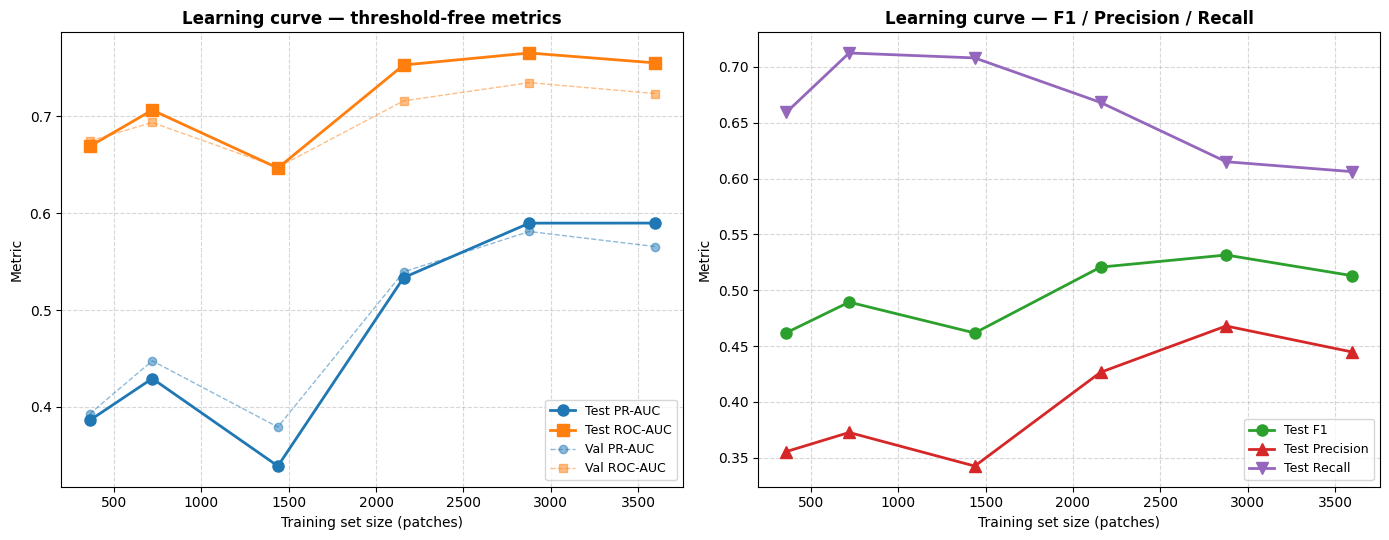

In [1]:
# ==========================================
# LEARNING CURVE PLOT
# ==========================================

# Drop failed runs
dfp = lc_df[lc_df.get('error').isna()] if 'error' in lc_df.columns else lc_df.copy()

# Auto-detect multi-seed: does any fraction have more than 1 run?
runs_per_frac = dfp.groupby('frac').size()
multi_seed = (runs_per_frac > 1).any()
print(f'Runs per fraction:\n{runs_per_frac.to_string()}')
print(f'Multi-seed mode: {multi_seed}\n')

if multi_seed:
    # Average across seeds; keep std for error bars
    dfp = dfp.groupby('frac', as_index=False).agg(
        n_train=('n_train', 'first'),
        test_pr_auc=('test_pr_auc', 'mean'),
        test_pr_auc_std=('test_pr_auc', 'std'),
        test_roc_auc=('test_roc_auc', 'mean'),
        test_roc_auc_std=('test_roc_auc', 'std'),
        test_f1=('test_f1', 'mean'),
        test_f1_std=('test_f1', 'std'),
        test_precision=('test_precision', 'mean'),
        test_precision_std=('test_precision', 'std'),
        test_recall=('test_recall', 'mean'),
        test_recall_std=('test_recall', 'std'),
        val_pr_auc=('val_pr_auc', 'mean'),
        val_roc_auc=('val_roc_auc', 'mean'),
    ).sort_values('n_train').reset_index(drop=True)

    # Fill NaN std (single-seed fractions) with 0
    for c in dfp.columns:
        if c.endswith('_std'):
            dfp[c] = dfp[c].fillna(0)
else:
    dfp = dfp.sort_values('n_train').reset_index(drop=True)
    # Add zero-std columns so the plotting code is identical
    for c in ['test_pr_auc', 'test_roc_auc', 'test_f1',
              'test_precision', 'test_recall']:
        dfp[f'{c}_std'] = 0.0

print('Final plotting table:')
print(dfp[['frac', 'n_train', 'test_pr_auc', 'test_roc_auc',
           'test_f1', 'test_precision', 'test_recall']].to_string(index=False))

# ---------- Plot ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Left panel: threshold-free metrics ---
ax = axes[0]

if multi_seed:
    ax.errorbar(dfp['n_train'], dfp['test_pr_auc'],
                yerr=dfp['test_pr_auc_std'],
                fmt='o-', color='tab:blue', lw=2, ms=8, capsize=5,
                label='Test PR-AUC')
    ax.errorbar(dfp['n_train'], dfp['test_roc_auc'],
                yerr=dfp['test_roc_auc_std'],
                fmt='s-', color='tab:orange', lw=2, ms=8, capsize=5,
                label='Test ROC-AUC')
else:
    ax.plot(dfp['n_train'], dfp['test_pr_auc'],  'o-',
            color='tab:blue', lw=2, ms=8, label='Test PR-AUC')
    ax.plot(dfp['n_train'], dfp['test_roc_auc'], 's-',
            color='tab:orange', lw=2, ms=8, label='Test ROC-AUC')

# Val curves (dotted, always plain)
ax.plot(dfp['n_train'], dfp['val_pr_auc'],  'o--',
        color='tab:blue', lw=1, ms=6, alpha=0.5, label='Val PR-AUC')
ax.plot(dfp['n_train'], dfp['val_roc_auc'], 's--',
        color='tab:orange', lw=1, ms=6, alpha=0.5, label='Val ROC-AUC')

ax.set_xlabel('Training set size (patches)')
ax.set_ylabel('Metric')
ax.set_title('Learning curve — threshold-free metrics', fontweight='bold')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)

# --- Right panel: F1 / Precision / Recall ---
ax = axes[1]

if multi_seed:
    ax.errorbar(dfp['n_train'], dfp['test_f1'],
                yerr=dfp['test_f1_std'],
                fmt='o-', color='tab:green', lw=2, ms=8, capsize=5,
                label='Test F1')
    ax.errorbar(dfp['n_train'], dfp['test_precision'],
                yerr=dfp['test_precision_std'],
                fmt='^-', color='tab:red', lw=2, ms=8, capsize=5,
                label='Test Precision')
    ax.errorbar(dfp['n_train'], dfp['test_recall'],
                yerr=dfp['test_recall_std'],
                fmt='v-', color='tab:purple', lw=2, ms=8, capsize=5,
                label='Test Recall')
else:
    ax.plot(dfp['n_train'], dfp['test_f1'],        'o-',
            color='tab:green',  lw=2, ms=8, label='Test F1')
    ax.plot(dfp['n_train'], dfp['test_precision'], '^-',
            color='tab:red',    lw=2, ms=8, label='Test Precision')
    ax.plot(dfp['n_train'], dfp['test_recall'],    'v-',
            color='tab:purple', lw=2, ms=8, label='Test Recall')

ax.set_xlabel('Training set size (patches)')
ax.set_ylabel('Metric')
ax.set_title('Learning curve — F1 / Precision / Recall', fontweight='bold')
ax.grid(True, ls='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(CFG.OUTPUTDIR / 'learning_curve.png', dpi=300)
plt.show()